# <u>Meteorite Threat Identification Binary Classification

#### Importing Libraries

In [1]:
# Essential modules 
import pandas as pd
import numpy as np

# Visualisation libraries 
import seaborn as sns
import matplotlib.pyplot as plt

# Normalization
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from scipy import stats

# Model Building
from sklearn import model_selection
from sklearn.model_selection import train_test_split,StratifiedKFold

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score

#### Uploading Data

In [2]:
train_df = pd.read_csv(r"C:\Users\HP\Downloads\JupyterNotebook\MachineLearning\Meteorite_Threat_Identification\train_dataset.csv")
train_df.head(10)

,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),Est Dia in Feet(max),Relative Velocity km per sec,...,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Hazardous
0,26.6,0.012722,0.028447,12.721988,28.447230,0.007905,0.017676,41.738807,93.330809,7.648194,...,7.583001,347.475804,443.098049,0.890218,245.671594,1.384692,2.457846e+06,125.647826,0.812461,0
1,22.7,0.076658,0.171412,76.657557,171.411509,0.047633,0.106510,251.501180,562.373736,19.142824,...,4.710039,176.203926,1107.448956,0.984464,175.628191,3.205210,2.457653e+06,113.100725,0.325071,0
2,24.0,0.042126,0.094198,42.126461,94.197631,0.026176,0.058532,138.210178,309.047354,7.819970,...,11.609153,146.961250,317.222445,0.828952,195.589585,0.991616,2.458100e+06,246.773198,1.134850,0
3,17.7,0.766576,1.714115,766.575574,1714.115092,0.476328,1.065101,2515.011805,5623.737359,2.335267,...,7.012588,354.475923,1036.204307,1.259659,105.208870,2.748343,2.457681e+06,111.130550,0.347422,0
4,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,1071.581063,30.994787,...,60.900589,219.323712,2174.260704,1.277179,218.504766,5.291914,2.458459e+06,284.064157,0.165574,0
5,19.6,0.319562,0.714562,319.561887,714.562102,0.198566,0.444008,1048.431420,2344.363926,10.818216,...,20.818153,224.034676,622.271419,1.030021,249.457621,1.822864,2.458184e+06,253.576803,0.578526,0
6,24.8,0.029144,0.065169,29.144390,65.168838,0.018109,0.040494,95.618082,213.808531,8.974451,...,2.472335,15.393584,442.216958,0.959662,102.399527,1.312232,2.458079e+06,296.167351,0.814080,0
7,21.2,0.152952,0.342011,152.951935,342.010925,0.095040,0.212516,501.810828,1122.083122,18.680560,...,5.517703,261.247146,832.360572,0.840977,87.110603,2.622444,2.458223e+06,263.620027,0.432505,1
8,18.7,0.483676,1.081534,483.676488,1081.533507,0.300543,0.672034,1586.865170,3548.338390,13.781134,...,24.383700,146.797855,271.215334,0.473852,153.200016,1.166136,2.457991e+06,13.262289,1.327359,0
9,23.1,0.063761,0.142574,63.760979,142.573883,0.039619,0.088591,209.189570,467.762099,12.650624,...,21.596245,219.339288,547.747534,1.028448,88.964780,1.591854,2.457968e+06,21.288718,0.657237,0


## Exploratory Data Analysis (EDA)

#### Data Types of each column

In [4]:
def printColumnTypes(df):
    non_num_df = df.select_dtypes(include=['object'])
    num_df = df.select_dtypes(exclude=['object'])
    '''separates non-numeric and numeric columns'''
    print("Non-Numeric columns:")
    for col in non_num_df:
        print(f"{col}")
    print("")
    print("Numeric columns:")
    for col in num_df:
        print(f"{col}")
printColumnTypes(train_df)

Non-Numeric columns:

Numeric columns:
Absolute Magnitude
Est Dia in KM(min)
Est Dia in KM(max)
Est Dia in M(min)
Est Dia in M(max)
Est Dia in Miles(min)
Est Dia in Miles(max)
Est Dia in Feet(min)
Est Dia in Feet(max)
Relative Velocity km per sec
Relative Velocity km per hr
Miles per hour
Miss Dist.(Astronomical)
Miss Dist.(lunar)
Miss Dist.(kilometers)
Miss Dist.(miles)
Orbit ID
Orbit Uncertainity
Minimum Orbit Intersection
Jupiter Tisserand Invariant
Epoch Osculation
Eccentricity
Semi Major Axis
Inclination
Asc Node Longitude
Orbital Period
Perihelion Distance
Perihelion Arg
Aphelion Dist
Perihelion Time
Mean Anomaly
Mean Motion
Hazardous


#### Checking for missing values

In [5]:
def missing_cols(df):
    '''prints out columns with its amount of missing values with its %'''
    total = 0
    for col in df.columns:
        missing_vals = df[col].isnull().sum()
        pct = df[col].isna().mean() * 100
        total += missing_vals
        if missing_vals != 0:
          print('{} => {} [{}%]'.format(col, df[col].isnull().sum(), round(pct, 2)))
    if total == 0:
        print("no missing values")
missing_cols(train_df)  

no missing values


#### Describing Data

In [16]:
train_df.describe()

,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),Est Dia in Feet(max),Relative Velocity km per sec,...,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Hazardous
count,3280.000000,3280.000000,3280.000000,3280.000000,3280.000000,3280.000000,3280.000000,3280.000000,3280.000000,3280.000000,...,3280.000000,3280.000000,3280.000000,3280.000000,3280.000000,3280.000000,3.280000e+03,3280.000000,3280.000000,3280.000000
mean,22.287687,0.197258,0.441082,197.257811,441.081875,0.122570,0.274075,647.171318,1447.119060,13.920372,...,13.473183,171.349646,638.009022,0.818517,184.229431,1.990773,2.457733e+06,182.515907,0.731585,0.160976
std,2.874909,0.276904,0.619175,276.903528,619.175112,0.172060,0.384737,908.476171,2031.414475,7.328379,...,10.946805,103.435107,367.985549,0.240366,103.201339,0.949144,9.234603e+02,107.526383,0.335232,0.367564
min,14.400000,0.001011,0.002260,1.010543,2.259644,0.000628,0.001404,3.315431,7.413530,0.335504,...,0.020987,0.001941,176.557161,0.080744,0.006918,0.803765,2.450854e+06,0.003191,0.140832,0.000000
25%,20.200000,0.033462,0.074824,33.462237,74.823838,0.020792,0.046493,109.784247,245.485039,8.422339,...,5.058736,81.585368,369.144783,0.640433,96.476530,1.273077,2.457813e+06,87.305972,0.455855,0.000000
50%,21.900000,0.110804,0.247765,110.803882,247.765013,0.068850,0.153954,363.529809,812.877364,12.888534,...,10.389875,172.451944,508.070867,0.840137,190.594667,1.620061,2.457975e+06,188.482062,0.708563,0.000000
75%,24.500000,0.242412,0.542051,242.412481,542.050786,0.150628,0.336815,795.316564,1778.381902,17.972776,...,19.762841,252.790804,789.724437,1.000085,272.468434,2.447108,2.458110e+06,276.559414,0.975227,0.000000
max,32.100000,3.503926,7.835018,3503.926411,7835.017643,2.177238,4.868453,11495.821927,25705.439285,44.633747,...,75.406667,359.905890,2556.242142,1.299832,359.929822,6.104579,2.458822e+06,359.917991,2.039000,1.000000


## Feature Selection & Engineering

#### Feature Selection using Correlation Matrix

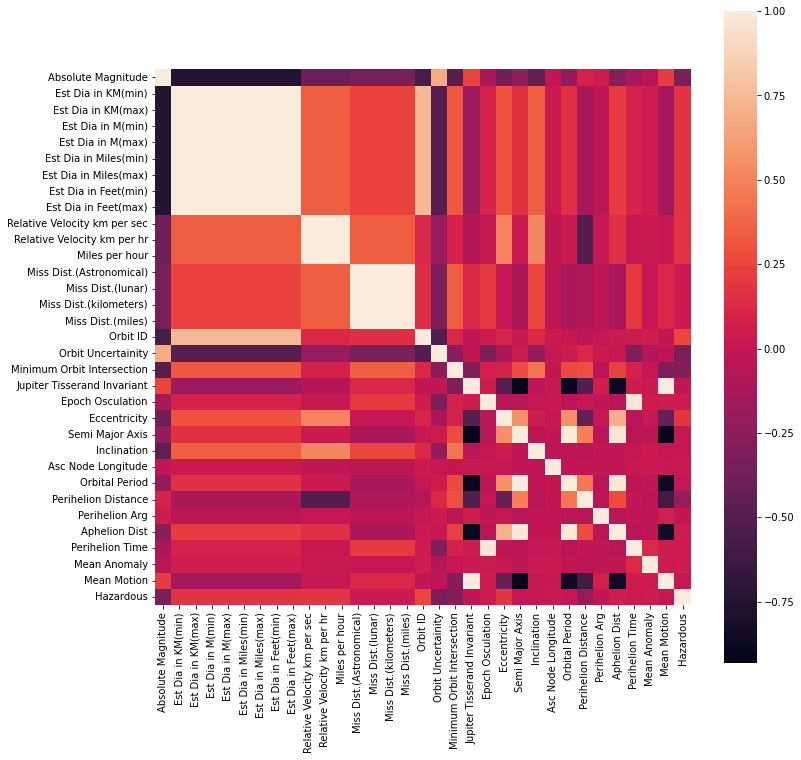

In [18]:
plt.figure(figsize = (12,12))
corrmat = df.corr()
ax = sns.heatmap(corrmat, vmax=1, square=True);

In [22]:
numeric_feature_cols = [x for x in df.columns if x not in ['Hazardous']]
target_col = ['Hazardous']

import scipy.stats 
corrs = []
for col in numeric_feature_cols:
    corr = scipy.stats.spearmanr(df['Hazardous'], df[col])
    corrs.append({
        'feature': col,
        'correlation': corr[0],
        'correlation_p_value': corr[1]
    })
pd.DataFrame(corrs).sort_values('correlation')

,feature,correlation,correlation_p_value
0,Absolute Magnitude,-0.341992,1.180936e-90
17,Orbit Uncertainity,-0.319934,5.946644e-79
18,Minimum Orbit Intersection,-0.299410,6.484723e-69
26,Perihelion Distance,-0.203424,5.626936e-32
19,Jupiter Tisserand Invariant,-0.021126,2.264270e-01
27,Perihelion Arg,-0.006704,7.011124e-01
31,Mean Motion,-0.006469,7.111395e-01
23,Inclination,-0.002344,8.932642e-01
22,Semi Major Axis,0.006469,7.111395e-01
25,Orbital Period,0.006469,7.111395e-01


In [55]:
X = train_df.drop(['Hazardous','Asc Node Longitude'], axis=1)
y = train_df['Hazardous']

#### Feature Engineering

In [24]:
def minmax_ratio_tx(min_data, max_data): 
    sub = max_data - min_data
    add = max_data + max_data
    
    minmax = sub/add
    minmax_02 = min_data/max_data
    return minmax, minmax_02

def quartile_transform(feature_data):
    qrtle_grp = feature_data.rank(pct=True,ascending=False)
    return qrtle_grp

In [25]:
to_quartile_grp = ['Minimum Orbit Intersection', 'Orbit Uncertainity', 'Aphelion Dist', 'Eccentricity', 'Perihelion Distance']

for grp in to_quartile_grp:
    X[grp + 'Quartile GRP'] = quartile_transform(X[grp])

In [26]:
to_minmax_ratio = [('Est Dia in Miles(min)', 'Est Dia in Miles(max)'),
                   ('Est Dia in M(min)', 'Est Dia in M(max)'),
                   ('Est Dia in KM(min)', 'Est Dia in KM(max)'), 
                   ('Est Dia in Feet(min)','Est Dia in Feet(max)')]

units = ["Miles", "M", "KM", "Feet"]
for minmax, unit in zip(to_minmax_ratio, units):
    print(minmax[0], minmax[1])
    min_ = X[minmax[0]]
    max_ = X[minmax[1]]
    X[ "Est Dia in " + unit + " Ratio"], X[unit+' minmax Ratio'] = minmax_ratio_tx(min_, max_)

Est Dia in Miles(min) Est Dia in Miles(max)
Est Dia in M(min) Est Dia in M(max)
Est Dia in KM(min) Est Dia in KM(max)
Est Dia in Feet(min) Est Dia in Feet(max)


## Splitting and Scaling

In [27]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size = 0.7, random_state=1)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_valid = scaler.transform(X_valid)

## Data Modelling

#### Baseline Machine Learning models: Classifiers with Default Hyperparameters

In [56]:
#Random Forest
clf = RandomForestClassifier()
clf.fit(X,y)
scores = cross_val_score(clf, X, y, cv=3,scoring='accuracy')
print("Accuracy:"+ str(scores.mean()))

Accuracy:0.9960362129400266


In [57]:
#SVM
from sklearn.svm import SVC,SVR
clf = SVC(gamma='scale')
clf.fit(X,y)
scores = cross_val_score(clf, X, y, cv=10,scoring='accuracy')
print("Accuracy:"+ str(scores.mean()))

Accuracy:0.8390243902439023


In [58]:
#LGBM
from lightgbm import LGBMClassifier
clf_lgbm = LGBMClassifier()
clf_lgbm.fit(X, y)
scores = cross_val_score(clf_lgbm, X, y, cv=3,scoring='accuracy')
print("Accuracy:"+ str(scores.mean()))

Accuracy:0.9951218573906412


In [59]:
#CatBoost
from catboost import CatBoostClassifier
clf =  CatBoostClassifier()    
clf.fit(X,y)
scores = cross_val_score(clf, X, y, cv=3,scoring='accuracy')
print("Accuracy:"+ str(scores.mean()))

Learning rate set to 0.017109
0:	learn: 0.6450624	total: 7.13ms	remaining: 7.12s
1:	learn: 0.5989058	total: 14.2ms	remaining: 7.07s
2:	learn: 0.5591366	total: 19.1ms	remaining: 6.35s
3:	learn: 0.5212673	total: 23.6ms	remaining: 5.89s
4:	learn: 0.4794701	total: 29.1ms	remaining: 5.79s
5:	learn: 0.4485218	total: 33.4ms	remaining: 5.53s
6:	learn: 0.4190049	total: 37.9ms	remaining: 5.38s
7:	learn: 0.3931659	total: 42.1ms	remaining: 5.22s
8:	learn: 0.3662045	total: 46.6ms	remaining: 5.13s
9:	learn: 0.3432661	total: 51ms	remaining: 5.05s
10:	learn: 0.3233286	total: 55.3ms	remaining: 4.97s
11:	learn: 0.3050309	total: 59.6ms	remaining: 4.91s
12:	learn: 0.2882201	total: 63.8ms	remaining: 4.84s
13:	learn: 0.2687599	total: 68ms	remaining: 4.79s
14:	learn: 0.2535008	total: 72.5ms	remaining: 4.76s
15:	learn: 0.2393599	total: 76.9ms	remaining: 4.73s
16:	learn: 0.2251713	total: 81.5ms	remaining: 4.71s
17:	learn: 0.2129679	total: 85.8ms	remaining: 4.68s
18:	learn: 0.2013244	total: 90.2ms	remaining: 4.

162:	learn: 0.0059092	total: 745ms	remaining: 3.82s
163:	learn: 0.0058439	total: 750ms	remaining: 3.82s
164:	learn: 0.0058016	total: 755ms	remaining: 3.82s
165:	learn: 0.0057517	total: 761ms	remaining: 3.82s
166:	learn: 0.0057455	total: 766ms	remaining: 3.82s
167:	learn: 0.0057164	total: 770ms	remaining: 3.81s
168:	learn: 0.0056580	total: 774ms	remaining: 3.81s
169:	learn: 0.0056504	total: 779ms	remaining: 3.81s
170:	learn: 0.0055892	total: 784ms	remaining: 3.8s
171:	learn: 0.0055851	total: 788ms	remaining: 3.79s
172:	learn: 0.0054832	total: 792ms	remaining: 3.79s
173:	learn: 0.0054495	total: 796ms	remaining: 3.78s
174:	learn: 0.0054443	total: 801ms	remaining: 3.77s
175:	learn: 0.0053982	total: 805ms	remaining: 3.77s
176:	learn: 0.0053401	total: 810ms	remaining: 3.76s
177:	learn: 0.0052889	total: 814ms	remaining: 3.76s
178:	learn: 0.0052783	total: 818ms	remaining: 3.75s
179:	learn: 0.0052626	total: 822ms	remaining: 3.75s
180:	learn: 0.0052333	total: 827ms	remaining: 3.74s
181:	learn: 0

355:	learn: 0.0027692	total: 1.66s	remaining: 3s
356:	learn: 0.0027684	total: 1.67s	remaining: 3s
357:	learn: 0.0027647	total: 1.67s	remaining: 2.99s
358:	learn: 0.0027623	total: 1.67s	remaining: 2.99s
359:	learn: 0.0027589	total: 1.68s	remaining: 2.98s
360:	learn: 0.0027343	total: 1.68s	remaining: 2.98s
361:	learn: 0.0027246	total: 1.69s	remaining: 2.98s
362:	learn: 0.0027117	total: 1.7s	remaining: 2.98s
363:	learn: 0.0026882	total: 1.7s	remaining: 2.97s
364:	learn: 0.0026772	total: 1.71s	remaining: 2.97s
365:	learn: 0.0026662	total: 1.71s	remaining: 2.96s
366:	learn: 0.0026632	total: 1.71s	remaining: 2.96s
367:	learn: 0.0026593	total: 1.72s	remaining: 2.95s
368:	learn: 0.0026547	total: 1.73s	remaining: 2.95s
369:	learn: 0.0026505	total: 1.73s	remaining: 2.95s
370:	learn: 0.0026490	total: 1.74s	remaining: 2.94s
371:	learn: 0.0026469	total: 1.74s	remaining: 2.94s
372:	learn: 0.0026450	total: 1.75s	remaining: 2.93s
373:	learn: 0.0026405	total: 1.75s	remaining: 2.93s
374:	learn: 0.002631

538:	learn: 0.0016400	total: 2.57s	remaining: 2.2s
539:	learn: 0.0016400	total: 2.58s	remaining: 2.2s
540:	learn: 0.0016400	total: 2.58s	remaining: 2.19s
541:	learn: 0.0016385	total: 2.59s	remaining: 2.19s
542:	learn: 0.0016309	total: 2.59s	remaining: 2.18s
543:	learn: 0.0016184	total: 2.6s	remaining: 2.18s
544:	learn: 0.0016165	total: 2.6s	remaining: 2.17s
545:	learn: 0.0016112	total: 2.61s	remaining: 2.17s
546:	learn: 0.0016112	total: 2.61s	remaining: 2.16s
547:	learn: 0.0016094	total: 2.62s	remaining: 2.16s
548:	learn: 0.0016084	total: 2.62s	remaining: 2.15s
549:	learn: 0.0016084	total: 2.63s	remaining: 2.15s
550:	learn: 0.0016084	total: 2.63s	remaining: 2.14s
551:	learn: 0.0016064	total: 2.63s	remaining: 2.14s
552:	learn: 0.0015974	total: 2.64s	remaining: 2.13s
553:	learn: 0.0015957	total: 2.64s	remaining: 2.13s
554:	learn: 0.0015944	total: 2.65s	remaining: 2.12s
555:	learn: 0.0015934	total: 2.65s	remaining: 2.12s
556:	learn: 0.0015908	total: 2.65s	remaining: 2.11s
557:	learn: 0.00

713:	learn: 0.0013479	total: 3.33s	remaining: 1.33s
714:	learn: 0.0013447	total: 3.34s	remaining: 1.33s
715:	learn: 0.0013447	total: 3.34s	remaining: 1.32s
716:	learn: 0.0013413	total: 3.35s	remaining: 1.32s
717:	learn: 0.0013413	total: 3.35s	remaining: 1.32s
718:	learn: 0.0013413	total: 3.36s	remaining: 1.31s
719:	learn: 0.0013413	total: 3.36s	remaining: 1.31s
720:	learn: 0.0013413	total: 3.37s	remaining: 1.3s
721:	learn: 0.0013407	total: 3.37s	remaining: 1.3s
722:	learn: 0.0013405	total: 3.37s	remaining: 1.29s
723:	learn: 0.0013399	total: 3.38s	remaining: 1.29s
724:	learn: 0.0013394	total: 3.38s	remaining: 1.28s
725:	learn: 0.0013394	total: 3.39s	remaining: 1.28s
726:	learn: 0.0013391	total: 3.39s	remaining: 1.27s
727:	learn: 0.0013357	total: 3.4s	remaining: 1.27s
728:	learn: 0.0013357	total: 3.4s	remaining: 1.26s
729:	learn: 0.0013325	total: 3.4s	remaining: 1.26s
730:	learn: 0.0013321	total: 3.41s	remaining: 1.25s
731:	learn: 0.0013318	total: 3.41s	remaining: 1.25s
732:	learn: 0.001

...

195:	learn: 0.0044204	total: 1.14s	remaining: 4.69s
196:	learn: 0.0043748	total: 1.15s	remaining: 4.68s
197:	learn: 0.0043293	total: 1.16s	remaining: 4.68s
198:	learn: 0.0042993	total: 1.16s	remaining: 4.67s
199:	learn: 0.0042707	total: 1.17s	remaining: 4.66s
200:	learn: 0.0042291	total: 1.17s	remaining: 4.66s
201:	learn: 0.0041815	total: 1.18s	remaining: 4.65s
202:	learn: 0.0041167	total: 1.18s	remaining: 4.64s
203:	learn: 0.0040749	total: 1.19s	remaining: 4.63s
204:	learn: 0.0040428	total: 1.19s	remaining: 4.63s
205:	learn: 0.0040352	total: 1.2s	remaining: 4.62s
206:	learn: 0.0039859	total: 1.2s	remaining: 4.61s
207:	learn: 0.0039611	total: 1.21s	remaining: 4.61s
208:	learn: 0.0039255	total: 1.21s	remaining: 4.59s
209:	learn: 0.0038924	total: 1.22s	remaining: 4.59s
210:	learn: 0.0038744	total: 1.23s	remaining: 4.58s
211:	learn: 0.0038319	total: 1.23s	remaining: 4.58s
212:	learn: 0.0037981	total: 1.24s	remaining: 4.57s
213:	learn: 0.0037647	total: 1.24s	remaining: 4.57s
214:	learn: 0.

381:	learn: 0.0018531	total: 2.23s	remaining: 3.61s
382:	learn: 0.0018501	total: 2.24s	remaining: 3.6s
383:	learn: 0.0018466	total: 2.24s	remaining: 3.6s
384:	learn: 0.0018352	total: 2.25s	remaining: 3.59s
385:	learn: 0.0018343	total: 2.26s	remaining: 3.59s
386:	learn: 0.0018305	total: 2.26s	remaining: 3.58s
387:	learn: 0.0018195	total: 2.27s	remaining: 3.58s
388:	learn: 0.0018179	total: 2.27s	remaining: 3.57s
389:	learn: 0.0018083	total: 2.28s	remaining: 3.56s
390:	learn: 0.0018071	total: 2.28s	remaining: 3.55s
391:	learn: 0.0017950	total: 2.29s	remaining: 3.55s
392:	learn: 0.0017842	total: 2.29s	remaining: 3.54s
393:	learn: 0.0017724	total: 2.3s	remaining: 3.53s
394:	learn: 0.0017628	total: 2.3s	remaining: 3.53s
395:	learn: 0.0017569	total: 2.31s	remaining: 3.52s
396:	learn: 0.0017439	total: 2.31s	remaining: 3.51s
397:	learn: 0.0017410	total: 2.32s	remaining: 3.51s
398:	learn: 0.0017269	total: 2.32s	remaining: 3.5s
399:	learn: 0.0017157	total: 2.33s	remaining: 3.49s
400:	learn: 0.001

540:	learn: 0.0011222	total: 3.17s	remaining: 2.69s
541:	learn: 0.0011160	total: 3.17s	remaining: 2.68s
542:	learn: 0.0011154	total: 3.18s	remaining: 2.67s
543:	learn: 0.0011120	total: 3.19s	remaining: 2.67s
544:	learn: 0.0011114	total: 3.19s	remaining: 2.67s
545:	learn: 0.0011062	total: 3.2s	remaining: 2.66s
546:	learn: 0.0011053	total: 3.21s	remaining: 2.66s
547:	learn: 0.0010994	total: 3.21s	remaining: 2.65s
548:	learn: 0.0010982	total: 3.22s	remaining: 2.65s
549:	learn: 0.0010927	total: 3.23s	remaining: 2.64s
550:	learn: 0.0010927	total: 3.23s	remaining: 2.63s
551:	learn: 0.0010896	total: 3.24s	remaining: 2.63s
552:	learn: 0.0010896	total: 3.25s	remaining: 2.62s
553:	learn: 0.0010844	total: 3.25s	remaining: 2.62s
554:	learn: 0.0010788	total: 3.26s	remaining: 2.61s
555:	learn: 0.0010788	total: 3.27s	remaining: 2.61s
556:	learn: 0.0010774	total: 3.27s	remaining: 2.6s
557:	learn: 0.0010766	total: 3.28s	remaining: 2.6s
558:	learn: 0.0010766	total: 3.29s	remaining: 2.59s
559:	learn: 0.0

700:	learn: 0.0008063	total: 4.26s	remaining: 1.81s
701:	learn: 0.0008028	total: 4.26s	remaining: 1.81s
702:	learn: 0.0008004	total: 4.27s	remaining: 1.8s
703:	learn: 0.0008004	total: 4.28s	remaining: 1.8s
704:	learn: 0.0008004	total: 4.28s	remaining: 1.79s
705:	learn: 0.0007980	total: 4.29s	remaining: 1.78s
706:	learn: 0.0007979	total: 4.29s	remaining: 1.78s
707:	learn: 0.0007955	total: 4.3s	remaining: 1.77s
708:	learn: 0.0007944	total: 4.3s	remaining: 1.77s
709:	learn: 0.0007920	total: 4.31s	remaining: 1.76s
710:	learn: 0.0007912	total: 4.32s	remaining: 1.75s
711:	learn: 0.0007904	total: 4.32s	remaining: 1.75s
712:	learn: 0.0007900	total: 4.33s	remaining: 1.74s
713:	learn: 0.0007877	total: 4.33s	remaining: 1.74s
714:	learn: 0.0007877	total: 4.34s	remaining: 1.73s
715:	learn: 0.0007856	total: 4.34s	remaining: 1.72s
716:	learn: 0.0007850	total: 4.35s	remaining: 1.72s
717:	learn: 0.0007824	total: 4.36s	remaining: 1.71s
718:	learn: 0.0007810	total: 4.36s	remaining: 1.71s
719:	learn: 0.00

871:	learn: 0.0007207	total: 5.35s	remaining: 786ms
872:	learn: 0.0007188	total: 5.36s	remaining: 779ms
873:	learn: 0.0007170	total: 5.36s	remaining: 773ms
874:	learn: 0.0007170	total: 5.37s	remaining: 767ms
875:	learn: 0.0007170	total: 5.38s	remaining: 761ms
876:	learn: 0.0007170	total: 5.38s	remaining: 755ms
877:	learn: 0.0007170	total: 5.39s	remaining: 749ms
878:	learn: 0.0007170	total: 5.39s	remaining: 743ms
879:	learn: 0.0007162	total: 5.4s	remaining: 736ms
880:	learn: 0.0007162	total: 5.4s	remaining: 730ms
881:	learn: 0.0007162	total: 5.41s	remaining: 724ms
882:	learn: 0.0007162	total: 5.41s	remaining: 717ms
883:	learn: 0.0007143	total: 5.42s	remaining: 711ms
884:	learn: 0.0007143	total: 5.42s	remaining: 705ms
885:	learn: 0.0007143	total: 5.43s	remaining: 699ms
886:	learn: 0.0007143	total: 5.43s	remaining: 692ms
887:	learn: 0.0007143	total: 5.44s	remaining: 686ms
888:	learn: 0.0007143	total: 5.45s	remaining: 680ms
889:	learn: 0.0007143	total: 5.45s	remaining: 674ms
890:	learn: 0.

#### Hyperparameter Optimization

In [64]:
# Grid search
from sklearn.model_selection import GridSearchCV
# Define the hyperparameter configuration space
rf_params = {
    'n_estimators': [10, 20, 30, 40],
    #'max_features': ['sqrt',0.5],
    'max_depth': [15,20,30,50],
    #'min_samples_leaf': [1,2,4,8],
    #"bootstrap":[True,False],
    "criterion":['gini','entropy']
}
clf = RandomForestClassifier(random_state=0)
grid = GridSearchCV(clf, rf_params, cv=3, scoring='accuracy')
grid.fit(X, y)
print(grid.best_params_)
print("Accuracy:"+ str(grid.best_score_))

{'criterion': 'gini', 'max_depth': 20, 'n_estimators': 40}
Accuracy:0.9957315206792101


## Prediction & Model Saving

In [68]:
test_df = pd.read_csv(r"C:\Users\HP\Downloads\JupyterNotebook\MachineLearning\Meteorite_Threat_Identification\test_dataset.csv")
test_df.head()

,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),Est Dia in Feet(max),Relative Velocity km per sec,...,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
0,25.1,0.025384,0.056760,25.383703,56.759685,0.015773,0.035269,83.279868,186.219446,4.581412,...,0.960067,6.856692,196.306187,343.597890,0.784560,128.552100,1.135574,2.457956e+06,46.850634,1.047736
1,20.6,0.201630,0.450858,201.629919,450.858206,0.125287,0.280150,661.515505,1479.193637,29.759711,...,1.313190,3.908082,3.756316,549.654306,0.343186,271.386905,2.283193,2.454734e+06,10.117600,0.654957
2,23.7,0.048368,0.108153,48.367649,108.153351,0.030054,0.067203,158.686517,354.833839,8.778408,...,2.829978,5.858230,157.020347,1738.893236,1.011426,344.511853,4.648529,2.458717e+06,211.595601,0.207028
3,18.4,0.555335,1.241767,555.334912,1241.766613,0.345069,0.771598,1821.964991,4074.037573,11.858580,...,1.153596,4.159055,337.201487,452.562947,0.606685,168.443407,1.700507,2.458040e+06,328.724516,0.795469
4,19.3,0.366906,0.820427,366.906138,820.427065,0.227985,0.509790,1203.760332,2691.689932,15.185391,...,1.342777,19.822195,64.003749,568.335056,0.842140,151.941979,1.843415,2.457925e+06,47.816955,0.633429


In [69]:
test_df  = test_df.drop(['Asc Node Longitude'], axis=1)     
X_train = X
y_train = y
print (X_train.shape, y_train.shape)
print (test_df.shape)                      

(3280, 31) (3280,)
(1407, 31)


In [71]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
test_prediction= clf.predict(test_df)

In [73]:
from pandas import DataFrame
df = DataFrame(test_prediction, columns=['Hazardous'])     
df

,Hazardous
0,0
1,1
2,0
3,0
4,0
...,...
1402,0
1403,0
1404,0
1405,0


In [74]:
df.to_csv(r".\Prediction_dataset.csv", index = False) 